Base geodesic: mu0 -> mu3
  signed shift delta03 = 0.400000000000

Initial HK tangent log_{mu0}(mu1):
  u01    = 0.198669330795
  beta01 = -0.009966711079

Parallel-transported tangent at mu3:
  u_pt    = 0.190749011514
  beta_pt = 0.029502791919

Resulting mu4 from the exact HK exponential map at mu3:
  support = [0.578210016518, 0.678210016518]
  density = 1.157878011994
  mass    = 0.115787801199

Particle pushforward check:
  particle mass = 0.115787801199
  exact mass    = 0.115787801199
  plot saved to /mnt/data/hk_pt_uniform_demo.png


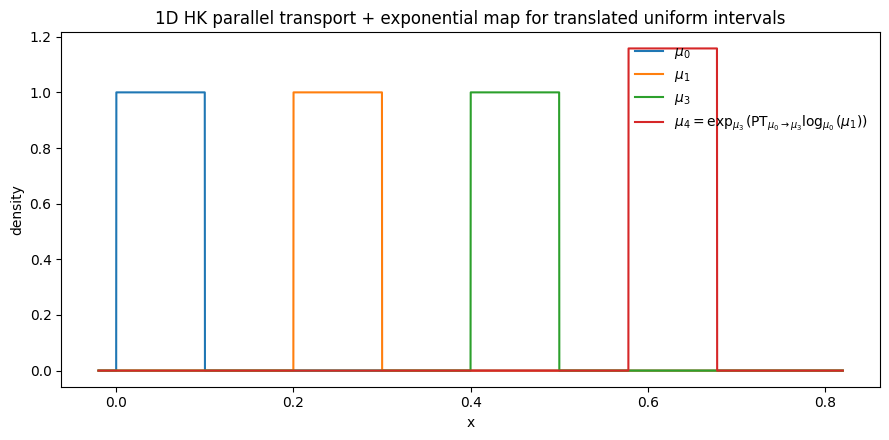

In [2]:
import math
from dataclasses import dataclass
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np


@dataclass
class UniformMeasure1D:
    left: float
    right: float
    density: float = 1.0

    @property
    def length(self) -> float:
        return self.right - self.left

    @property
    def mass(self) -> float:
        return self.density * self.length


# -----------------------------------------------------------------------------
# HK conventions matched to the uploaded code:
#   partial_t mu + partial_x(mu v) = 4 beta mu
#   hk_exponential_map uses
#       q_t = sqrt((t v)^2 + (1 + 2 t beta)^2)
#       phi_t = atan2(t v, 1 + 2 t beta)
#       x -> x + phi_t,   density -> density * q_t^2
# For a translation by signed angle delta with equal endpoint densities, the exact
# initial HK tangent is therefore
#       v = sin(delta),   beta = (cos(delta) - 1)/2.
# -----------------------------------------------------------------------------


def exact_translation_tangent(delta: float) -> Tuple[float, float]:
    """Exact HK tangent generating a translation by signed amount delta."""
    return math.sin(delta), 0.5 * (math.cos(delta) - 1.0)



def q_phi_from_constant_tangent(v: float, beta: float, t: float) -> Tuple[float, float]:
    """Exact q_t and phi_t under the module's HK exponential-map normalization."""
    q = math.sqrt((t * v) ** 2 + (1.0 + 2.0 * t * beta) ** 2)
    phi = math.atan2(t * v, 1.0 + 2.0 * t * beta)
    return q, phi



def base_curve_fields(delta: float, t: float) -> Tuple[float, float, float, float]:
    """
    Eulerian fields along the HK geodesic from a translated uniform interval.

    Returns:
        q_t, phi_t, v_t, alpha_t
    where the curve is
        mu_t = q_t^2 * Unif[left + phi_t, right + phi_t],
    and alpha_t is the reaction field in the base dynamics.
    """
    v0, alpha0 = exact_translation_tangent(delta)
    q_t, phi_t = q_phi_from_constant_tangent(v0, alpha0, t)
    denom = q_t * q_t
    v_t = v0 / denom
    alpha_t = (t * v0 * v0 + 2.0 * alpha0 * (1.0 + 2.0 * t * alpha0)) / (2.0 * denom)
    return q_t, phi_t, v_t, alpha_t



def integrate_parallel_transport(delta_base: float, delta_source: float, nt: int = 5000) -> Tuple[np.ndarray, np.ndarray]:
    """
    Integrate the 1D HK parallel-transport PDE along characteristics.

    In the present translated-uniform setting, all spatial derivatives vanish, so
    the PDE reduces to the ODE system
        u' + 2 alpha_t u + 2 beta v_t = 0,
        beta' + 2 alpha_t beta - 0.5 v_t u = 0.

    The returned arrays contain the full time history of (u_t, beta_t).
    """
    if nt <= 0:
        raise ValueError("nt must be positive")

    times = np.linspace(0.0, 1.0, nt + 1)
    u_hist = np.zeros(nt + 1, dtype=float)
    beta_hist = np.zeros(nt + 1, dtype=float)

    u_hist[0], beta_hist[0] = exact_translation_tangent(delta_source)

    def rhs(t: float, y: np.ndarray) -> np.ndarray:
        u, beta = float(y[0]), float(y[1])
        _, _, v_t, alpha_t = base_curve_fields(delta_base, t)
        return np.array([
            -2.0 * alpha_t * u - 2.0 * beta * v_t,
            0.5 * v_t * u - 2.0 * alpha_t * beta,
        ])

    dt = 1.0 / nt
    y = np.array([u_hist[0], beta_hist[0]], dtype=float)
    for k in range(nt):
        t = times[k]
        k1 = rhs(t, y)
        k2 = rhs(t + 0.5 * dt, y + 0.5 * dt * k1)
        k3 = rhs(t + 0.5 * dt, y + 0.5 * dt * k2)
        k4 = rhs(t + dt, y + dt * k3)
        y = y + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        u_hist[k + 1] = y[0]
        beta_hist[k + 1] = y[1]

    return u_hist, beta_hist



def hk_exponential_of_uniform(measure: UniformMeasure1D, v: float, beta: float) -> UniformMeasure1D:
    """Apply the exact HK exponential map of a constant tangent to a uniform interval."""
    q1, phi1 = q_phi_from_constant_tangent(v, beta, t=1.0)
    return UniformMeasure1D(
        left=measure.left + phi1,
        right=measure.right + phi1,
        density=measure.density * q1 * q1,
    )



def density_on_grid(measure: UniformMeasure1D, grid: np.ndarray) -> np.ndarray:
    out = np.zeros_like(grid, dtype=float)
    mask = (grid >= measure.left) & (grid <= measure.right)
    out[mask] = measure.density
    return out



def particle_pushforward(measure: UniformMeasure1D, v: float, beta: float, n_particles: int = 1000) -> Tuple[np.ndarray, np.ndarray]:
    """
    Particle realization of the exact HK exponential map, used only for a visual check.

    Particles start with equal masses approximating the input density. The exact HK
    exponential rescales every particle mass by q_1^2 and shifts every particle by
    the same phi_1 in this constant-tangent translated-uniform setting.
    """
    xs = np.linspace(measure.left, measure.right, n_particles, endpoint=False)
    dx = measure.length / n_particles
    weights = np.full(n_particles, measure.density * dx, dtype=float)
    q1, phi1 = q_phi_from_constant_tangent(v, beta, t=1.0)
    ys = xs + phi1
    new_weights = weights * q1 * q1
    return ys, new_weights



def main() -> None:
    mu0 = UniformMeasure1D(0.0, 0.1, density=1.0)
    mu1 = UniformMeasure1D(0.2, 0.3, density=1.0)
    mu3 = UniformMeasure1D(0.4, 0.5, density=1.0)

    delta01 = mu1.left - mu0.left
    delta03 = mu3.left - mu0.left

    # 1) Exact HK tangent sending mu0 to mu1.
    u01, beta01 = exact_translation_tangent(delta01)

    # 2) Parallel transport that tangent along the HK geodesic mu0 -> mu3.
    u_hist, beta_hist = integrate_parallel_transport(delta03, delta01, nt=5000)
    u_pt = float(u_hist[-1])
    beta_pt = float(beta_hist[-1])

    # 3) Exponential map at mu3 of the transported tangent.
    mu4 = hk_exponential_of_uniform(mu3, u_pt, beta_pt)

    # 4) Build a grid and visualize densities.
    grid = np.linspace(-0.02, 0.82, 4000)
    rho0 = density_on_grid(mu0, grid)
    rho1 = density_on_grid(mu1, grid)
    rho3 = density_on_grid(mu3, grid)
    rho4 = density_on_grid(mu4, grid)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(grid, rho0, label=r"$\mu_0$")
    ax.plot(grid, rho1, label=r"$\mu_1$")
    ax.plot(grid, rho3, label=r"$\mu_3$")
    ax.plot(grid, rho4, label=r"$\mu_4 = \exp_{\mu_3}(\mathrm{PT}_{\mu_0\to\mu_3}\log_{\mu_0}(\mu_1))$")
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.set_title("1D HK parallel transport + exponential map for translated uniform intervals")
    ax.legend(loc="upper right", frameon=False)
    fig.tight_layout()
    # fig.savefig("/mnt/data/hk_pt_uniform_demo.png", dpi=200)

    # Particle check.
    ys, ws = particle_pushforward(mu3, u_pt, beta_pt, n_particles=1000)
    particle_mass = float(np.sum(ws))
    exact_mass = mu4.mass

    print("Base geodesic: mu0 -> mu3")
    print(f"  signed shift delta03 = {delta03:.12f}")
    print()
    print("Initial HK tangent log_{mu0}(mu1):")
    print(f"  u01    = {u01:.12f}")
    print(f"  beta01 = {beta01:.12f}")
    print()
    print("Parallel-transported tangent at mu3:")
    print(f"  u_pt    = {u_pt:.12f}")
    print(f"  beta_pt = {beta_pt:.12f}")
    print()
    print("Resulting mu4 from the exact HK exponential map at mu3:")
    print(f"  support = [{mu4.left:.12f}, {mu4.right:.12f}]")
    print(f"  density = {mu4.density:.12f}")
    print(f"  mass    = {mu4.mass:.12f}")
    print()
    print("Particle pushforward check:")
    print(f"  particle mass = {particle_mass:.12f}")
    print(f"  exact mass    = {exact_mass:.12f}")
    print(f"  plot saved to /mnt/data/hk_pt_uniform_demo.png")


if __name__ == "__main__":
    main()


Truncated-normal demo finished.
n_particles = 1200
time steps  = 4000

Subcritical check:
  max |mu1-mu0| quantile displacement = 0.550000000000
  max |mu3-mu0| quantile displacement = 0.670000000000
  pi/2                               = 1.570796326795

mu4 summary:
  mass(mu4)   = 1.712924895827
  mean(mu4)   = 1.063048490541
  support(mu4)= [0.964252388127, 1.161844592956]

Transported tangent summary at mu3:
  mean(v_pt)     = 0.501273779748
  mean(beta_pt)  = 0.104493484987
  min(v_pt)      = 0.501273779748
  max(v_pt)      = 0.501273779748
  min(beta_pt)   = 0.104493484987
  max(beta_pt)   = 0.104493484987



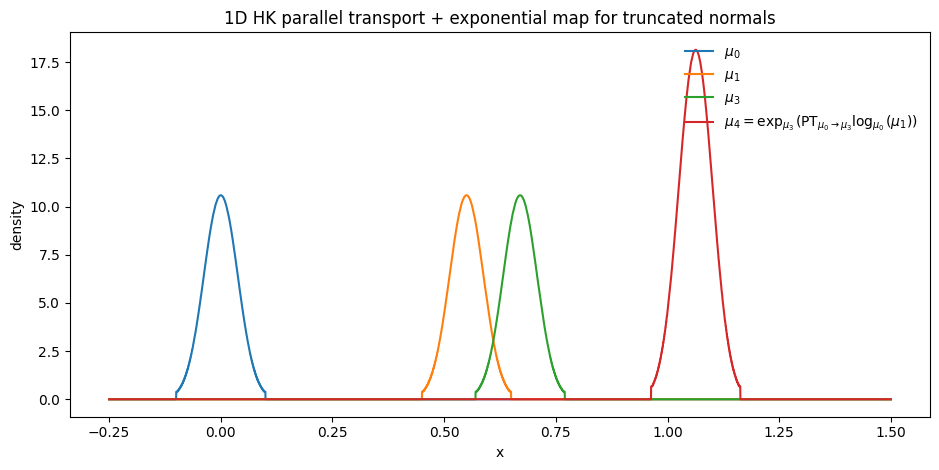

In [ ]:
import math
from dataclasses import dataclass
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import truncnorm


# -----------------------------------------------------------------------------
# 1D HK particle method for truncated normals in the subcritical regime.
#
# Convention matched to the uploaded code:
#   partial_t mu + partial_x(mu v) = 4 beta mu
#   q_t   = sqrt((t v)^2 + (1 + 2 t beta)^2)
#   phi_t = atan2(t |v|, 1 + 2 t beta)
#   x     -> x + sign(v) * phi_t
#   mass  -> mass * q_t^2
#
# For a signed endpoint displacement theta in (-pi/2, pi/2), the exact source
# tangent that generates that displacement over one unit of time is
#   v0    = sin(|theta|) * sign(theta)
#   beta0 = (cos(|theta|) - 1) / 2.
# -----------------------------------------------------------------------------


@dataclass
class TruncatedNormal1D:
    mean: float
    sigma: float
    left: float
    right: float

    def dist(self):
        a = (self.left - self.mean) / self.sigma
        b = (self.right - self.mean) / self.sigma
        return truncnorm(a, b, loc=self.mean, scale=self.sigma)

    def pdf(self, x: np.ndarray) -> np.ndarray:
        return self.dist().pdf(x)

    def ppf(self, p: np.ndarray) -> np.ndarray:
        return self.dist().ppf(p)


@dataclass
class ParticleMeasure1D:
    x: np.ndarray
    w: np.ndarray


@dataclass
class ParticleTangent1D:
    v: np.ndarray
    beta: np.ndarray


@dataclass
class DemoResult:
    mu0: ParticleMeasure1D
    mu1: ParticleMeasure1D
    mu3: ParticleMeasure1D
    mu4: ParticleMeasure1D
    tangent_01: ParticleTangent1D
    tangent_pt: ParticleTangent1D
    x03_paths: np.ndarray
    r03_paths: np.ndarray
    t_grid: np.ndarray


def discretize_truncnorm_equal_mass(measure: TruncatedNormal1D, n_particles: int) -> ParticleMeasure1D:
    p = (np.arange(n_particles, dtype=float) + 0.5) / n_particles
    x = measure.ppf(p)
    w = np.full(n_particles, 1.0 / n_particles, dtype=float)
    return ParticleMeasure1D(x=x, w=w)



def signed_hk_log_from_endpoint_map(x_src: np.ndarray, x_tgt: np.ndarray) -> ParticleTangent1D:
    theta = x_tgt - x_src
    abs_theta = np.abs(theta)
    if np.any(abs_theta >= np.pi / 2):
        raise ValueError("Encountered displacement >= pi/2; outside the subcritical HK regime.")

    v = np.sin(abs_theta) * np.sign(theta)
    beta = 0.5 * (np.cos(abs_theta) - 1.0)
    return ParticleTangent1D(v=v, beta=beta)



def q_phi_from_tangent(v: np.ndarray, beta: np.ndarray, t: float) -> Tuple[np.ndarray, np.ndarray]:
    q = np.sqrt((t * np.abs(v)) ** 2 + (1.0 + 2.0 * t * beta) ** 2)
    phi = np.arctan2(t * np.abs(v), 1.0 + 2.0 * t * beta)
    return q, phi



def exact_base_geodesic_paths(x0: np.ndarray, x3: np.ndarray, t_grid: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    base_tan = signed_hk_log_from_endpoint_map(x0, x3)
    signs = np.sign(base_tan.v)

    x_paths = np.zeros((len(t_grid), len(x0)), dtype=float)
    r_paths = np.zeros_like(x_paths)
    for k, t in enumerate(t_grid):
        q_t, phi_t = q_phi_from_tangent(base_tan.v, base_tan.beta, float(t))
        x_paths[k] = x0 + signs * phi_t
        r_paths[k] = q_t
    return x_paths, r_paths



def base_fields_along_geodesic(v0: np.ndarray, beta0: np.ndarray, t: float) -> Tuple[np.ndarray, np.ndarray]:
    q_t, _ = q_phi_from_tangent(v0, beta0, t)
    denom = q_t**2
    v_t = v0 / denom
    alpha_t = (t * v0**2 + 2.0 * beta0 * (1.0 + 2.0 * t * beta0)) / (2.0 * denom)
    return v_t, alpha_t



def integrate_parallel_transport_ode(
    base_geodesic_tangent: ParticleTangent1D,
    source_tangent: ParticleTangent1D,
    nt: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Solve the 1D HK parallel-transport PDE along characteristics.

    For each particle/characteristic, we integrate the ODE system
        u'    + 2 alpha_t u + 2 beta v_t = 0,
        beta' + 2 alpha_t beta - 0.5 v_t u = 0,
    corresponding to the note you asked for.
    """
    t_grid = np.linspace(0.0, 1.0, nt + 1)
    n = len(base_geodesic_tangent.v)
    u_hist = np.zeros((nt + 1, n), dtype=float)
    b_hist = np.zeros((nt + 1, n), dtype=float)
    u_hist[0] = source_tangent.v
    b_hist[0] = source_tangent.beta

    y_u = source_tangent.v.copy()
    y_b = source_tangent.beta.copy()
    dt = 1.0 / nt

    def rhs(t: float, u: np.ndarray, b: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        v_t, alpha_t = base_fields_along_geodesic(base_geodesic_tangent.v, base_geodesic_tangent.beta, t)
        du = -2.0 * alpha_t * u - 2.0 * b * v_t
        db = 0.5 * v_t * u - 2.0 * alpha_t * b
        return du, db

    for k in range(nt):
        t = t_grid[k]
        k1u, k1b = rhs(t, y_u, y_b)
        k2u, k2b = rhs(t + 0.5 * dt, y_u + 0.5 * dt * k1u, y_b + 0.5 * dt * k1b)
        k3u, k3b = rhs(t + 0.5 * dt, y_u + 0.5 * dt * k2u, y_b + 0.5 * dt * k2b)
        k4u, k4b = rhs(t + dt, y_u + dt * k3u, y_b + dt * k3b)
        y_u = y_u + (dt / 6.0) * (k1u + 2.0 * k2u + 2.0 * k3u + k4u)
        y_b = y_b + (dt / 6.0) * (k1b + 2.0 * k2b + 2.0 * k3b + k4b)
        u_hist[k + 1] = y_u
        b_hist[k + 1] = y_b

    return t_grid, u_hist, b_hist



def hk_exponential_pushforward(mu: ParticleMeasure1D, tangent: ParticleTangent1D) -> ParticleMeasure1D:
    q1, phi1 = q_phi_from_tangent(tangent.v, tangent.beta, 1.0)
    x_new = mu.x + np.sign(tangent.v) * phi1
    w_new = mu.w * q1**2
    return ParticleMeasure1D(x=x_new, w=w_new)



def particle_density_on_grid(mu: ParticleMeasure1D, grid: np.ndarray) -> np.ndarray:
    """Piecewise-constant density based on Voronoi cells around sorted particles."""
    order = np.argsort(mu.x)
    x = mu.x[order]
    w = mu.w[order]

    mids = 0.5 * (x[:-1] + x[1:])
    left_bd = x[0] - 0.5 * (x[1] - x[0])
    right_bd = x[-1] + 0.5 * (x[-1] - x[-2])
    boundaries = np.concatenate(([left_bd], mids, [right_bd]))
    cell_lengths = boundaries[1:] - boundaries[:-1]
    rho = w / cell_lengths

    out = np.zeros_like(grid, dtype=float)
    for i in range(len(x)):
        mask = (grid >= boundaries[i]) & (grid < boundaries[i + 1])
        out[mask] = rho[i]
    out[grid == boundaries[-1]] = rho[-1]
    return out



def compute_demo(
    n_particles: int = 1200,
    nt: int = 4000,
    sigma0: float = 0.038,
    sigma1: float = 0.038,
    sigma3: float = 0.038,
) -> DemoResult:
    # Same support windows as the uniform experiment, but with different sigmas so
    # the result is not just a trivial translation of the same density shape.
    nu0 = TruncatedNormal1D(mean=0.0, sigma=sigma0, left=-0.1, right=0.1)
    nu1 = TruncatedNormal1D(mean=0.55, sigma=sigma1, left=0.45, right=0.55)
    nu3 = TruncatedNormal1D(mean=0.67, sigma=sigma3, left=-5.0, right=5.0)

    mu0 = discretize_truncnorm_equal_mass(nu0, n_particles)
    mu1 = discretize_truncnorm_equal_mass(nu1, n_particles)
    mu3 = discretize_truncnorm_equal_mass(nu3, n_particles)

    max_disp = max(np.max(np.abs(mu1.x - mu0.x)), np.max(np.abs(mu3.x - mu0.x)))
    if max_disp >= np.pi / 2:
        raise ValueError("The chosen supports leave the subcritical regime.")

    tangent_01 = signed_hk_log_from_endpoint_map(mu0.x, mu1.x)
    tangent_03 = signed_hk_log_from_endpoint_map(mu0.x, mu3.x)

    t_grid, u_hist, b_hist = integrate_parallel_transport_ode(tangent_03, tangent_01, nt=nt)
    tangent_pt = ParticleTangent1D(v=u_hist[-1].copy(), beta=b_hist[-1].copy())

    mu4 = hk_exponential_pushforward(mu3, tangent_pt)
    x03_paths, r03_paths = exact_base_geodesic_paths(mu0.x, mu3.x, t_grid)

    return DemoResult(
        mu0=mu0,
        mu1=mu1,
        mu3=mu3,
        mu4=mu4,
        tangent_01=tangent_01,
        tangent_pt=tangent_pt,
        x03_paths=x03_paths,
        r03_paths=r03_paths,
        t_grid=t_grid,
    )



def main() -> None:
    result = compute_demo()

    grid = np.linspace(-0.25, 1.5, 6000)
    rho0 = particle_density_on_grid(result.mu0, grid)
    rho1 = particle_density_on_grid(result.mu1, grid)
    rho3 = particle_density_on_grid(result.mu3, grid)
    rho4 = particle_density_on_grid(result.mu4, grid)

    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    ax.plot(grid, rho0, label=r"$\mu_0$")
    ax.plot(grid, rho1, label=r"$\mu_1$")
    ax.plot(grid, rho3, label=r"$\mu_3$")
    ax.plot(grid, rho4, label=r"$\mu_4 = \exp_{\mu_3}(\mathrm{PT}_{\mu_0\to\mu_3}\log_{\mu_0}(\mu_1))$")
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.set_title("1D HK parallel transport + exponential map for truncated normals")
    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()
    # fig.savefig("/mnt/data/hk_pt_truncnorm_demo.png", dpi=200)

    mean4 = float(np.sum(result.mu4.x * result.mu4.w) / np.sum(result.mu4.w))
    mass4 = float(np.sum(result.mu4.w))
    support4 = (float(np.min(result.mu4.x)), float(np.max(result.mu4.x)))

    print("Truncated-normal demo finished.")
    print(f"n_particles = {len(result.mu0.x)}")
    print(f"time steps  = {len(result.t_grid)-1}")
    print()
    print("Subcritical check:")
    print(f"  max |mu1-mu0| quantile displacement = {np.max(np.abs(result.mu1.x - result.mu0.x)):.12f}")
    print(f"  max |mu3-mu0| quantile displacement = {np.max(np.abs(result.mu3.x - result.mu0.x)):.12f}")
    print(f"  pi/2                               = {0.5*np.pi:.12f}")
    print()
    print("mu4 summary:")
    print(f"  mass(mu4)   = {mass4:.12f}")
    print(f"  mean(mu4)   = {mean4:.12f}")
    print(f"  support(mu4)= [{support4[0]:.12f}, {support4[1]:.12f}]")
    print()
    print("Transported tangent summary at mu3:")
    print(f"  mean(v_pt)     = {np.mean(result.tangent_pt.v):.12f}")
    print(f"  mean(beta_pt)  = {np.mean(result.tangent_pt.beta):.12f}")
    print(f"  min(v_pt)      = {np.min(result.tangent_pt.v):.12f}")
    print(f"  max(v_pt)      = {np.max(result.tangent_pt.v):.12f}")
    print(f"  min(beta_pt)   = {np.min(result.tangent_pt.beta):.12f}")
    print(f"  max(beta_pt)   = {np.max(result.tangent_pt.beta):.12f}")
    print()


if __name__ == "__main__":
    main()
